Pizza Hourly Revenue Prediction Modelling Notebook
-

# Loading Preprocessed Data

In [1]:
import sklearn
import numpy as np
import pandas as pd

In [2]:
# Loading model inputs
X_train = pd.read_parquet('../preprocessed_data/X_train.parquet')
X_test = pd.read_parquet('../preprocessed_data/X_test.parquet')

# loading model targets
y_train = pd.read_parquet('../preprocessed_data/train_targets.parquet')
y_test = pd.read_parquet('../preprocessed_data/test_targets.parquet')

# Loading entire training and test dataframes
train_df = pd.read_parquet('../preprocessed_data/train_df.parquet')
test_df = pd.read_parquet('../preprocessed_data/test_df.parquet')

#loading hourly pizza dataframes
pizza_hourly = pd.read_parquet('../preprocessed_data/pizza_hourly.parquet')

# Creating a quick and easy basline model 
**To bench mark future models**
> - We'd try a dumb model that returns the mean of the sales value of the hours
> - we'll also try a Linear regression baseline model although it's not suitable in this case



## Model that returns mean

In [3]:
# Creating hourly mean revenue dataframe
mean_hourly_revenue = pizza_hourly.groupby('hour').revenue.mean().reset_index()

In [4]:
# Creating a dictionary of hourly mean revenue
hourly_mean = mean_hourly_revenue.set_index('hour')['revenue'].to_dict()

In [5]:
hourly_mean

{9: 83.0,
 10: 37.95625,
 11: 135.75770392749246,
 12: 313.38347338935574,
 13: 296.27290502793295,
 14: 169.63151862464184,
 15: 149.27408450704226,
 16: 196.78483146067413,
 17: 241.56148459383752,
 18: 250.1312324929972,
 19: 203.44229691876748,
 20: 165.38465909090908,
 21: 123.25454545454546,
 22: 82.66358695652174,
 23: 43.12884615384615}

In [6]:
# defining a function to predict inputs
def predict_mean_rev(inputs):
    inputs = pd.DataFrame(inputs)
    hour = inputs.hour
    return inputs.hour.map(hourly_mean) #hourly_mean.get(hour)
    

In [7]:
y_pred = predict_mean_rev(test_df)

In [8]:
# Importing Evaluation metrics
from sklearn.metrics import median_absolute_error

In [9]:
mae = median_absolute_error

In [10]:
mae(y_test, y_pred)

np.float64(74.27408450704226)

Our basline model has a median absolute error of $74

## Baseline regression model

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
base_model = LinearRegression()

In [13]:
base_model.fit(X_train, y_train)

LinearRegression()

In [14]:
preds = base_model.predict(X_test)

In [15]:
mae(y_test, preds)

np.float64(67.22392695532602)

- Our regression model has a test error of $67

# Training a tree based model

## Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

In [17]:
# defining a simple function to train and evualation random forest predictions

def RF( X_train, y_train, X_test, y_test, **params) :
    y_train = y_train.to_numpy().ravel()
    
    model = RandomForestRegressor(n_jobs=-1, random_state = 42, **params)
    
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_error = mae(y_train, train_preds)
    test_error = mae(y_test, test_preds)
    return train_error, test_error

In [18]:
RF(X_train, y_train, X_test, y_test,)

(np.float64(24.344499999999996), np.float64(74.60050000000003))

## hyper tunning Random Forest model

### max_depth

In [19]:
RF( X_train, y_train, X_test, y_test, max_depth = 1)

(np.float64(82.32923366492452), np.float64(86.87923366492446))

In [20]:
RF( X_train, y_train, X_test, y_test,max_depth = 2)

(np.float64(80.575), np.float64(83.59794818337372))

In [21]:
RF( X_train, y_train, X_test, y_test,max_depth = 4)

(np.float64(71.59694944948328), np.float64(75.25163519395929))

In [22]:
RF( X_train, y_train, X_test, y_test,max_depth = 8)

(np.float64(64.84116503981332), np.float64(71.10618639295024))

In [23]:
RF( X_train, y_train, X_test, y_test,max_depth = 16)

(np.float64(49.70292724253379), np.float64(69.97521344360155))

In [24]:
RF( X_train, y_train, X_test, y_test,max_depth = 20)

(np.float64(42.81322891078375), np.float64(70.52984847230269))

The max_depth with the best test accuracy is the 16 at $69.97 median absolute error

### n_estimators

In [25]:
RF( X_train, y_train, X_test, y_test,n_estimators = 10)

(np.float64(22.837499999999977), np.float64(80.42500000000001))

In [26]:
RF( X_train, y_train, X_test, y_test,n_estimators = 20)

(np.float64(23.998749999999994), np.float64(76.87499999999994))

In [27]:
RF( X_train, y_train, X_test, y_test,n_estimators = 40)

(np.float64(23.54625), np.float64(74.69000000000005))

In [28]:
RF( X_train, y_train, X_test, y_test,n_estimators = 80)

(np.float64(24.107187499999995), np.float64(75.79874999999998))

In [29]:
RF( X_train, y_train, X_test, y_test,)

(np.float64(24.344499999999996), np.float64(74.60050000000003))

In [30]:
RF( X_train, y_train, X_test, y_test,n_estimators = 200)

(np.float64(24.192749999999947), np.float64(73.41975000000005))

In [31]:
RF( X_train, y_train, X_test, y_test,n_estimators = 400)

(np.float64(24.283124999999927), np.float64(74.15787499999996))

The  n_estimator paramter with the lowest error is at 200 at $73.4

### min_sample_split

In [32]:
RF( X_train, y_train, X_test, y_test,min_samples_split = 3)

(np.float64(26.981671428571435), np.float64(74.88152976190474))

In [33]:
RF( X_train, y_train, X_test, y_test,min_samples_split = 4)

(np.float64(29.084860119047647), np.float64(74.40654583333333))

In [34]:
RF( X_train, y_train, X_test, y_test, min_samples_split = 5)

(np.float64(31.413043290043305), np.float64(74.79698134920636))

In [35]:
RF( X_train, y_train, X_test, y_test, min_samples_split = 8)

(np.float64(37.51644393325864), np.float64(74.60680990814737))

In [36]:
RF( X_train, y_train, X_test, y_test, min_samples_split = 16)

(np.float64(47.33091647177672), np.float64(72.63265017072868))

The best for min_sample_split is at 16 with a Medae of $72.6

### Max_features

In [37]:
RF( X_train, y_train, X_test, y_test, max_features=0.5)

(np.float64(24.183749999999918), np.float64(71.02449999999996))

In [38]:
RF(X_train, y_train, X_test, y_test, max_features=0.75)

(np.float64(24.029999999999987), np.float64(71.40400000000022))

In [39]:
RF( X_train, y_train, X_test, y_test, max_features=0.4)

(np.float64(24.34674999999997), np.float64(70.14349999999997))

The best fit for max_features is at max_features 0.4 with a Medae of $70.1

### hyperparameters combinations

In [40]:
RF( X_train, y_train, X_test, y_test, max_features=0.75, min_samples_split = 8, n_estimators = 200, max_depth = 16)

(np.float64(53.97816933279976), np.float64(69.07257422900398))

In [41]:
RF( X_train, y_train, X_test, y_test, min_samples_split = 8, n_estimators = 200, max_depth = 16)

(np.float64(54.246492305903345), np.float64(69.54716129150864))

In [42]:
RF( X_train, y_train, X_test, y_test, n_estimators = 49, max_depth = 8, min_samples_split = 6)

(np.float64(64.92277279909644), np.float64(71.11126644042108))

- The best combination and Random Forest model trained was with  (min_samples_split = 8, n_estimators = 200, max_depth = 16) with an error if $69

## Xgboost

In [43]:
from xgboost import XGBRegressor

In [44]:
# defining a function to train and evaulate XGBoost Modeld
def xgb(**params):
    model = XGBRegressor(random_state = 42, n_jobs = -1, **params)
    model.fit(X_train, y_train)
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    train_error = mae(y_train, train_preds)
    test_error = mae(y_test, test_preds)
    return train_error, test_error

In [45]:
xgb()

(np.float64(48.057151794433594), np.float64(71.18522949218749))

## Hpertunning Xgboost

### Max_depth

In [46]:
xgb(max_depth = 1)

(np.float64(65.44058227539062), np.float64(71.04158020019531))

In [47]:
xgb(max_depth = 2)

(np.float64(61.72660446166992), np.float64(69.21066284179688))

In [48]:
xgb(max_depth = 3)

(np.float64(58.94940185546875), np.float64(68.59938964843752))

In [49]:
xgb(max_depth = 4)

(np.float64(55.67888793945312), np.float64(71.56486511230469))

In [50]:
xgb(max_depth = 5)

(np.float64(52.946739196777344), np.float64(73.29164123535156))

In [51]:
xgb(max_depth = 8)

(np.float64(36.094573974609375), np.float64(73.8897644042969))

In [52]:
def xgb_md_error(md):
    model = XGBRegressor(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds2 = model.predict(X_train)
    train_error = mae(preds2, y_train)
    test_error = mae(preds, y_test)
    return {'Max Depth': md, 'Training Error': train_error, 'Test Error': test_error}

In [53]:
import os

In [54]:
%%time
errors_df = pd.DataFrame([xgb_md_error(md) for md in range(1, 21)])
errors_df

CPU times: total: 58.4 s
Wall time: 15.1 s


,Max Depth,Training Error,Test Error
0,1,65.440582,71.041580
1,2,61.726604,69.210663
2,3,58.949402,68.599390
3,4,55.678888,71.564865
4,5,52.946739,73.291641
5,6,48.057152,71.185229
6,7,42.779289,74.771701
7,8,36.094574,73.889764
8,9,31.606448,75.661621
9,10,24.717249,76.868338


The best fit for maxdepth is 3 with an erro rof $68.6

### n_estimators

In [55]:
xgb(n_estimators = 10)

(np.float64(61.797523498535156), np.float64(72.78471374511719))

In [56]:
xgb(n_estimators = 20)

(np.float64(58.94428863525391), np.float64(69.97775268554688))

In [57]:
xgb(n_estimators = 40)

(np.float64(55.27049255371094), np.float64(70.46804809570312))

In [58]:
xgb(n_estimators = 80)

(np.float64(50.20437469482422), np.float64(71.17411041259766))

In [59]:
xgb(n_estimators = 100)

(np.float64(48.057151794433594), np.float64(71.18522949218749))

In [60]:
xgb(n_estimators = 200)

(np.float64(39.36198806762695), np.float64(71.5015899658203))

In [61]:
xgb(n_estimators = 400)

(np.float64(27.78875732421875), np.float64(78.94921112060547))

The best fit for n_estimators (number of trees) is 20 with an error of $69.9

### max_leaves

In [62]:
xgb(max_leaves = 1)

(np.float64(85.875), np.float64(93.58372497558594))

In [63]:
xgb(max_leaves = 2)

(np.float64(65.44058227539062), np.float64(71.04158020019531))

In [64]:
xgb(max_leaves = 4)

(np.float64(61.23203735351562), np.float64(68.85166931152344))

In [65]:
xgb(max_leaves = 8)

(np.float64(58.85152053833008), np.float64(72.20384216308594))

The best for for max_leafs max_leaves is 4 eith an errror of $68.9

### hyperparameters combinations

In [66]:
xgb(max_leaves = 3 , n_estimators =4000, learning_rate = 0.1)

(np.float64(60.617835998535156), np.float64(68.60506439208984))

In [67]:
xgb(max_leaves = 3 , n_estimators =4000)

(np.float64(60.32270431518555), np.float64(67.02366638183594))

In [68]:
xgb(max_leaves = 3 , n_estimators =4000, learning_rate = 0.1, max_depth = 3)

(np.float64(60.617835998535156), np.float64(68.60506439208984))

In [69]:
xgb(max_depth = 8, n_estimators =4000)

(np.float64(0.005795288085934658), np.float64(83.97063636779785))

In [70]:
xgb(max_depth = 4, n_estimators =4000)

(np.float64(6.419918060302734), np.float64(83.44816589355469))

In [71]:
xgb(max_depth = 2, n_estimators =4000)

(np.float64(47.9793815612793), np.float64(79.46546936035156))

In [72]:
xgb( tree_method = 'hist', grow_policy = 'lossguide', max_leaves = 64, max_depth = 0)

(np.float64(27.573225402832037), np.float64(76.0697021484375))

In [73]:
xgb( tree_method = 'hist', grow_policy = 'lossguide', max_leaves = 128, max_depth = 0)

(np.float64(12.959644317626953), np.float64(77.65310668945312))

- The best hyperparameter is (max_leaves = 3 , n_estimators =4000) with an error of $67

## Decision tree

In [74]:
from sklearn.tree import DecisionTreeRegressor

In [75]:
# Defining a function to train and evualte our Decison tree model
def DT(**Params):
    model = DecisionTreeRegressor(random_state=42, **Params)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds2 = model.predict(X_train)
    train_error = mae(preds2, y_train)
    test_error = mae(preds, y_test)
    return train_error, test_error

In [76]:
DT()

(np.float64(0.0), np.float64(90.64999999999998))

## Hypertuning decison tree

### Max_depth 

In [77]:
DT(max_depth = 2)

(np.float64(80.79994804294927), np.float64(85.50005195705072))

In [78]:
DT(max_depth = 4)

(np.float64(71.47688407990238), np.float64(77.66091101694761))

In [79]:
DT(max_depth = 8)

(np.float64(61.50273257548141), np.float64(73.14770408163275))

In [80]:
DT(max_depth = 16)

(np.float64(36.66037781195907), np.float64(77.59473684210528))

In [81]:
def max_depth_error(md):
    model = DecisionTreeRegressor(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    preds2 = model.predict(X_train)
    train_error = mae(preds2, y_train)
    test_error = mae(preds, y_test)
    return {'Max Depth': md, 'Training Error': train_error, 'Test Error': test_error}

In [82]:
import os

In [83]:
%%time
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])
errors_df

CPU times: total: 1.05 s
Wall time: 1.04 s


,Max Depth,Training Error,Test Error
0,1,82.415212,89.515212
1,2,80.799948,85.500052
2,3,74.725000,80.732637
3,4,71.476884,77.660911
4,5,68.015003,76.633131
5,6,65.815812,76.563817
6,7,63.808384,73.707959
7,8,61.502733,73.147704
8,9,60.504983,74.328106
9,10,58.627000,73.168898


- The best max_depth for our model is at 8 with an error of $73.4

### Max_features

In [84]:
DT(min_samples_split = 88)

(np.float64(57.063306834361654), np.float64(75.835))

In [85]:
DT(min_samples_split = 10)

(np.float64(25.760416666666657), np.float64(87.81250000000006))

In [86]:
DT(min_samples_split = 20)

(np.float64(40.62777777777779), np.float64(81.24473684210525))

In [87]:
DT(min_samples_split = 40)

(np.float64(52.7852272727273), np.float64(76.71666666666664))

In [88]:
DT(min_samples_split = 60)

(np.float64(55.81416223404254), np.float64(77.905))

In [89]:
DT(min_samples_split = 80)

(np.float64(56.47179487179487), np.float64(76.17391304347836))

The best fit for minsample split is at 88 with an error of $75.8

### max_leaf_nodes

In [90]:
DT(max_leaf_nodes=128)

(np.float64(57.44999999999999), np.float64(65.98452380952382))

In [91]:
DT(max_leaf_nodes=256)

(np.float64(52.03298507462709), np.float64(70.15000000000009))

In [92]:
DT(max_leaf_nodes=512)

(np.float64(42.74569666576302), np.float64(73.29523809523812))

The best fit is of max_leaf_nodes is 128 with an error of appproximately $68

# Retraining model on the entire datastet
> **NOTE:** I choose Xgboost instead of decision tree because it combines many trees leading to better genralization. It is more likely to perform more consistently on new and slightly differnt data even though the descison tree had a slightly lower mae

In [93]:
inputs = pd.read_parquet('../preprocessed_data/Ed.parquet')

In [94]:
targets = pd.read_parquet('../preprocessed_data/Ed_targets.parquet')

In [95]:
model = XGBRegressor(random_state = 42, n_jobs = -1, max_leaves = 3 , n_estimators =4000)
model.fit(inputs, targets)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=3, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=4000,
             n_jobs=-1, num_parallel_tree=None, ...)

## Saving model

In [96]:
import joblib

In [97]:
pizza_sales_model = {
    'model': model,
}

In [98]:
joblib.dump(pizza_sales_model, '../models/pizza_sales_model.joblib')

['../models/pizza_sales_model.joblib']

# Prediction of single inputs and creating single input function

In [99]:
single_input  = {
    'date': '2016-4-23',
    'hour': 13,
}

In [100]:
pizza_preprocessing = joblib.load('../models/preprocessing_pipeline.joblib')

In [101]:
def parse_date(input_df):
    input_df['date'] = pd.to_datetime(input_df['date'])
    input_df['Day'] = input_df.date.dt.day
    input_df['Month'] = input_df.date.dt.month
    input_df['Day_of_week'] = input_df.date.dt.day_name()
    input_df['is_weekend'] = input_df['Day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
    input_df['hour_of_day'] = input_df['hour'].astype(str) + '_' + input_df['Day_of_week'].astype(str)

    
def predict_input(single_input, encoder, categorical_cols, model):
    input_df = pd.DataFrame([single_input])
    parse_date(input_df)
    input_df = input_df.drop(columns = ['date'], axis=1)

    # Transform cateorical cols
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
    input_df_encoded= pd.DataFrame(encoder.transform(input_df[categorical_cols]), columns=encoded_cols, index=input_df.index)
    input_df = pd.concat([input_df.drop(columns=categorical_cols), input_df_encoded], axis =1)

    pred = model.predict(input_df)[0]

    return pred
    
    

In [102]:
encoder = pizza_preprocessing['encoder']
categorical_cols = pizza_preprocessing['categorical_cols']
pizza_model = joblib.load('../models/pizza_sales_model.joblib')
model = pizza_model['model']
model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=3, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=4000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [103]:
encoder

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [104]:
predict_input(single_input, encoder, categorical_cols, model)

np.float32(245.71284)

# Project overview and model evaulaution

The model lacks predictive features as the two inputed features date and time are not enough to severly outperform a basline model thatt predicts hourly mean 
- The model should include features like weather, individual store info , region/location et
-  most of the hourly revenue pattern is covered by the hour feature(extracted from time)
- The baseline model had a median absolute error of 74 while our best tree models error was 67 suprising our linear regression baseline error is $67

## Feature importance

In [109]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [114]:
# Creating dataframe of feature and importance
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df

,feature,importance
14,hour_22,0.145788
13,hour_21,0.126191
10,hour_18,0.090785
9,hour_17,0.074160
5,hour_13,0.057346
...,...,...
60,hour_of_day_10_Wednesday,0.000000
134,hour_of_day_21_Sunday,0.000000
147,hour_of_day_23_Saturday,0.000000
148,hour_of_day_23_Sunday,0.000000


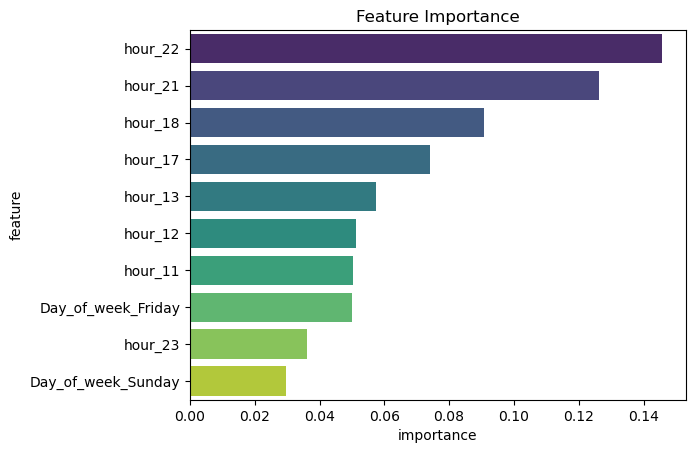

In [110]:
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis', hue='feature')
plt.title('Feature Importance')
plt.show()

AS We can ssee the hour feature is the single most important feature 

## Model comparison plot

In [111]:
errors = {
    'Baseline_model': 74.3,
    'Linear_regression': 67.2,
    'Random Forest': 69.1,
    'Xgboost': 67,
    'Decison Tree': 65.9,
}

In [112]:
models = list(errors.keys())
mae = list(errors.values())

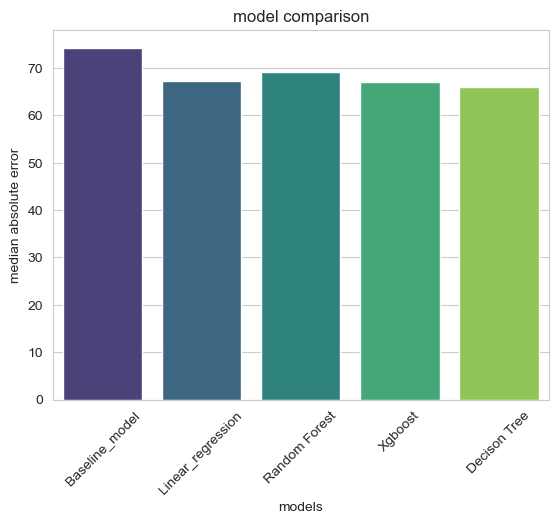

In [113]:
# plotting comparison plot
sns.set_style('whitegrid')
sns.barplot(x=models, y=mae, palette='viridis', hue=models)

plt.ylabel('median absolute error')
plt.xticks(rotation= 45)
plt.xlabel('models')
plt.title('model comparison')
plt.show()